# Download and prepare `PPFD_IN` (2004-2025)

**notebook version**: `1` (19 Jul 2026)

## ℹ️ About this notebook

Downloads screened photosynthetic photon flux density `PPFD_IN` from the InfluxDB database,
merges the data sources into one continuous series, applies the 2012 corrections, removes the
nighttime zero-offset, gap-fills the result and stores it to the external data folder.

Same structure as notebooks `01` (`SW_IN`) and `02` (`TA`), with two differences noted in the
gap-filling section.

**Output columns:**

- `PPFD_IN_T1_47_1_gfXG` — the gap-filled series (µmol m⁻² s⁻¹, complete, non-negative)
- `FLAG_PPFD_IN_T1_47_1_ISFILLED` — how each record was obtained; `0` = measured, `>0` = filled

**Notebook `01` has to be run before this one**: its gap-filled `SW_IN` is the driver here.

***

# Info about data sources

- `PPFD_IN_T1_47_1`: mst (2004-2021), diive (2022-2025)
- **There is no NABEL PPFD sensor**, so unlike `SW_IN` and `TA` there is no second instrument of
  the same kind. The driver is the gap-filled `SW_IN` from notebook `01`, which is complete over
  the whole record and physically almost proportional to `PPFD_IN`.
- Measurements start on **2004-09-20**. Everything before that is filled — see the note in the
  export section.

Legend:
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`.

***

# ⚙️ Settings

## Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "PPFD_IN_T1_47_1"

OUTNAME = "03_METEO_PPFD_IN_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Gap-filled SW_IN produced by notebook 01, used here as the driver.
SWIN_FILE = "01_METEO_SW_IN_GAPFILLED_2004-2025"
SWIN_COL = "SW_IN_T1_47_1_gfXG"

## Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-20 01:02:57
diive version: v0.91.0


In [3]:
# 0/1/2 are the standard diive gap-filling flags. 3 marks nighttime records set to zero by
# physics and 4 short gaps filled by interpolation, matching the codes used in notebooks 01/02.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = gap-filled by the XGBoost model',
    2: '2 = gap-filled by the timestamp-only fallback model (a driver was missing)',
    3: '3 = nighttime gap, set to zero by physics',
    4: '4 = gap-filled by linear interpolation (short gap)',
}

## Plot helpers

In [4]:
def plot_gapfill_panels(gapfilled, flag, title, ylabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
                        figsize=(16, 7)):
    """Three panels: measured only, the final series, and the fills on their own."""
    _plotdf = pd.DataFrame({
        'observed': gapfilled.where(flag == 0),
        'gapfilled': gapfilled,
        'gap values': gapfilled.where(flag > 0),
    })
    axs = _plotdf.plot(subplots=True, figsize=figsize, x_compat=True, alpha=.9,
                       title=title, legend=True)
    for ax in axs:
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    return axs


def plot_pred_vs_measured(model, title, unit=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$'):
    """Predicted against measured on the HELD-OUT test set, plus residuals."""
    test = model.traintest_details_['test_df']
    measured = test[model.target_col].values
    predicted = model.model_.predict(test.drop(columns=model.target_col))
    residual = predicted - measured
    rmse = float(np.sqrt((residual ** 2).mean()))

    fig, axs = plt.subplots(ncols=2, figsize=(13, 5.5), dpi=100, layout='constrained')
    fig.suptitle(f"{title}  (held-out test set, n={len(test):,})", fontsize=13)
    axs[0].hexbin(measured, predicted, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    lim = [float(min(measured.min(), predicted.min())), float(max(measured.max(), predicted.max()))]
    axs[0].plot(lim, lim, 'r-', lw=1.2, label='1:1')
    axs[0].set_xlabel(f'measured {unit}'); axs[0].set_ylabel(f'predicted {unit}')
    axs[0].set_title(f'RMSE {rmse:.2f}   bias {float(residual.mean()):+.2f}', fontsize=11)
    axs[0].legend(fontsize=8)
    axs[1].hexbin(predicted, residual, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    axs[1].axhline(0, color='r', lw=1.2)
    axs[1].set_xlabel(f'predicted {unit}'); axs[1].set_ylabel(f'residual {unit}')
    axs[1].set_title('Residuals', fontsize=11)
    return fig


def fill_stats_by_year(flag, legend=None):
    """Records per year and flag, plus a stacked bar chart of the filled ones."""
    legend = legend or FLAG_LEGEND
    tab = (pd.crosstab(flag.index.year, flag)
             .rename(columns=lambda f: legend.get(f, f))
             .rename_axis(index='year', columns=None))
    filled = tab.drop(columns=[c for c in tab.columns if str(c).startswith('0 =')], errors='ignore')
    if not filled.empty and filled.to_numpy().sum() > 0:
        ax = filled.plot(kind='bar', stacked=True, figsize=(14, 4), title='Filled records per year')
        ax.set_ylabel('records'); ax.legend(fontsize=8)
        plt.tight_layout()
    return tab

## 🔌 Connect to database

In [5]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

# ⬇️ Download

`mst` covers 2004-2021, `diive` covers 2022-2025. They do not overlap.

In [6]:
%%time

BUCKET = 'ch-lae_processed'
MEASUREMENTS = ['PPFD']

mst_ppfd, _, _ = dbc.download(
    bucket=BUCKET, measurements=MEASUREMENTS, fields=[TARGET],
    start='2004-01-01 00:00:01', stop='2022-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_mst')

diive_ppfd, _, _ = dbc.download(
    bucket=BUCKET, measurements=MEASUREMENTS, fields=[TARGET],
    start='2022-01-01 00:00:01', stop='2026-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive')

mst_ppfd = TimestampSanitizer(data=mst_ppfd, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()
diive_ppfd = TimestampSanitizer(data=diive_ppfd, output_middle_timestamp=True,
                                nominal_freq=REQUIRED_TIME_RESOLUTION).get()
print(f"mst:   {mst_ppfd[TARGET].notna().sum():,} records")
print(f"diive: {diive_ppfd[TARGET].notna().sum():,} records")

> DOWNLOADING from bucket ch-lae_processed: variables ['PPFD_IN_T1_47_1'] from measurements 
['PPFD'], data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['PPFD_IN_T1_47_1'] from measurements 
['PPFD'], data version ['meteoscreening_diive'], between 2022-01-01 00:00:01 and 2026-01-01 00:00:01
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

mst:   300,291 records
diive: 70,046 records
CPU times: total: 6.2 s
Wall time: 9.02 s


## Merge onto one continuous 30MIN index

In [7]:
full_index = pd.date_range('2004-01-01 00:15:00', '2025-12-31 23:45:00', freq='30min',
                           name='TIMESTAMP_MIDDLE')
ppfd_2004_2025 = pd.DataFrame(index=full_index)
ppfd_2004_2025[TARGET] = (mst_ppfd[TARGET]
                          .combine_first(diive_ppfd[TARGET])
                          .reindex(full_index))
print(f"{TARGET}: {ppfd_2004_2025[TARGET].notna().sum():,} of {len(ppfd_2004_2025):,} records")
print(f"first measurement: {ppfd_2004_2025[TARGET].first_valid_index()}")
ppfd_2004_2025

PPFD_IN_T1_47_1: 370,337 of 385,728 records
first measurement: 2004-09-20 10:45:00


,PPFD_IN_T1_47_1
TIMESTAMP_MIDDLE,
2004-01-01 00:15:00,NaN
2004-01-01 00:45:00,NaN
2004-01-01 01:15:00,NaN
2004-01-01 01:45:00,NaN
2004-01-01 02:15:00,NaN
...,...
2025-12-31 21:45:00,0.0
2025-12-31 22:15:00,0.0
2025-12-31 22:45:00,0.0


## Heatmap

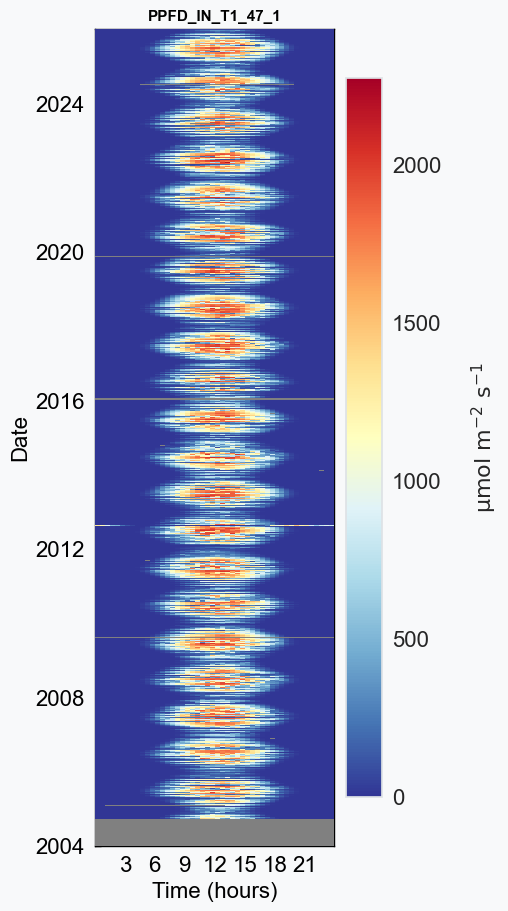

In [8]:
fig, ax = plt.subplots(figsize=(5, 9), dpi=100, layout="constrained")
dv.plotting.HeatmapDateTime(series=ppfd_2004_2025[TARGET]).plot(
    ax=ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
    format_style=dv.plotting.FormatStyle(title=TARGET, title_fontsize=11))

***

# ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

A logger clock error affects every variable that logger recorded. `PPFD_IN` shows the same
`+15.5 h` shift as `SW_IN` and `TA` on 10-16 August, so the same correction is applied.

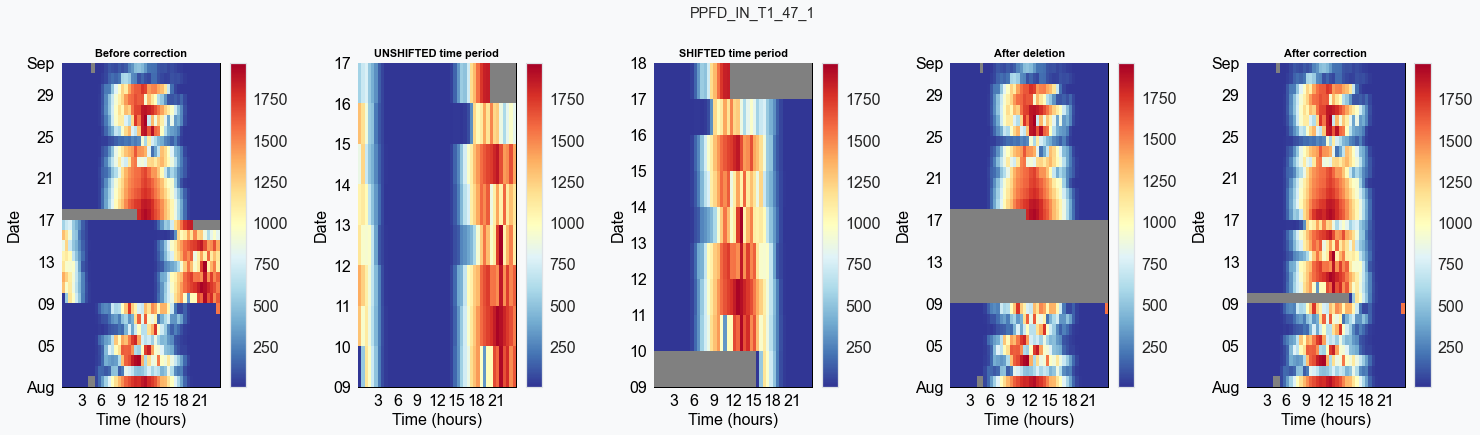

In [9]:
AFFECTED_VARS = [TARGET]
_df = ppfd_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before, ax_unshifted, ax_shifted, ax_after, ax_corrected = [
        fig.add_subplot(gs[0, i]) for i in range(5)]

    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy().dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

In [10]:
ppfd_2004_2025 = _df.copy()
ppfd_2004_2025

,PPFD_IN_T1_47_1
TIMESTAMP_MIDDLE,
2004-01-01 00:15:00,NaN
2004-01-01 00:45:00,NaN
2004-01-01 01:15:00,NaN
2004-01-01 01:45:00,NaN
2004-01-01 02:15:00,NaN
...,...
2025-12-31 21:45:00,0.0
2025-12-31 22:15:00,0.0
2025-12-31 22:45:00,0.0


### Power failure and storm damage, 2012

The same three damaged windows removed in notebooks `01` and `02` apply to `PPFD_IN` as well.
Aligning `PPFD_IN` against the NABEL `SW_IN` sensor (the only instrument at the site not on the
affected logger) day by day, after scaling PPFD to W m-2 equivalent so the errors are comparable:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-28 | 0 | 49 | 49 |
| 2012-08-02 | 0 | 199 | 199 |
| 2012-08-09 | -32.5 h | 151 | 462 |
| **2012-08-11** | **+15.5 h** | **48** | 572 |
| **2012-08-16** | **+15.5 h** | **78** | 460 |
| 2012-08-18 | 0 | 34 | 34 |
| 2012-10-27 | 0 | 11 | 11 |
| 2012-10-30 | -24.0 h | 178 | 210 |
| 2012-11-05 | -24.0 h | 146 | 172 |
| 2012-11-11 | 0 | 6 | 6 |

The picture matches `SW_IN` and `TA` exactly: a clean `+15.5 h` clock offset on 10-16 August
(fixed by the correction above), an unrepairable degradation from 29 July to 9 August, and a
second unrepairable period from late October to early November. The fieldbook attributes the
first to a tower power supply failure repaired on 9 August, and the second to storm damage with
cable work on 6 November. Notebooks `01` and `02` document the evidence in full.

Windows are on the **corrected** time axis and are identical to those used there.

Removed 1213 degraded records from PPFD_IN_T1_47_1 (gap-filled later).


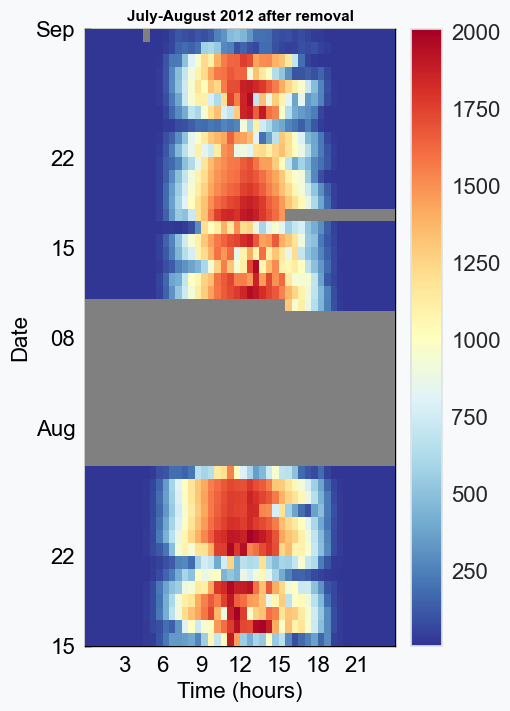

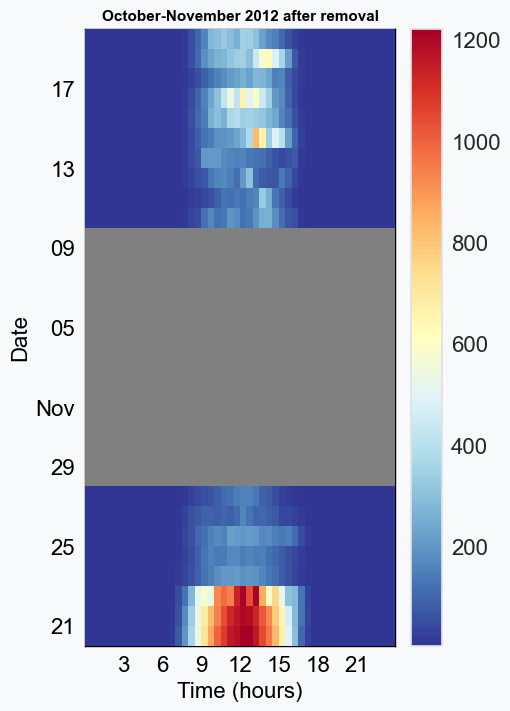

In [11]:
# Identical to the windows removed in notebooks 01 and 02 - the faults are in the logger and
# the power supply, so every variable on that system is affected.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

_before = int(ppfd_2004_2025[TARGET].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    _locs = (ppfd_2004_2025.index >= _start) & (ppfd_2004_2025.index <= _end)
    ppfd_2004_2025.loc[_locs, TARGET] = np.nan
_removed = _before - int(ppfd_2004_2025[TARGET].notna().sum())
print(f"Removed {_removed} degraded records from {TARGET} (gap-filled later).")

for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, ax = plt.subplots(figsize=(5, 7), dpi=100, layout="constrained")
    _show = (ppfd_2004_2025.index >= _lo) & (ppfd_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=ppfd_2004_2025.loc[_show, TARGET]).plot(
        ax=ax, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(
            title=f'{_label} 2012 after removal', title_fontsize=11))

### Nighttime zero-offset

`PPFD_IN` must read zero at night. A sensor that does not is carrying an offset, which
`dv.corrections.remove_nighttime_zero_offset` removes: for each day it takes the mean of that
day's nighttime values as the offset, subtracts it from the whole day, then sets nighttime to
zero and clamps the remaining negatives to zero. It is the same routine notebook `01` applies to
`SW_IN` through `correct_nighttime_offset=True`, called directly here because `PPFD_IN` has no
dedicated gap-filling class.

**The gap mask has to be taken before this step.** The correction sets every nighttime record to
zero, and it does not distinguish a nighttime measurement from a nighttime gap — the missing ones
become zero too. Asking the corrected series which records are missing therefore reports no
nighttime gaps at all, and they would be exported as `0 = observed` when they are really fills.
`PPFD_ORIGINAL_GAPS` is captured first and carried into the gap-filler, which flags them `3`.

gaps before correction: 16,604


> running remove_nighttime_zero_offset ...

before: min 0.00, records below zero: 0
after : min 0.00, records below zero: 0
mean change on measured records: -2.935 umol m-2 s-1
nighttime gaps zeroed by the correction: 7,543 (fills, not measurements - flagged 3 by the gap-filler)


,PPFD_IN_T1_47_1
count,376667.000000
mean,284.502278
std,484.057175
min,0.000000
25%,0.000000
50%,2.655310
75%,358.031093
max,2271.086339


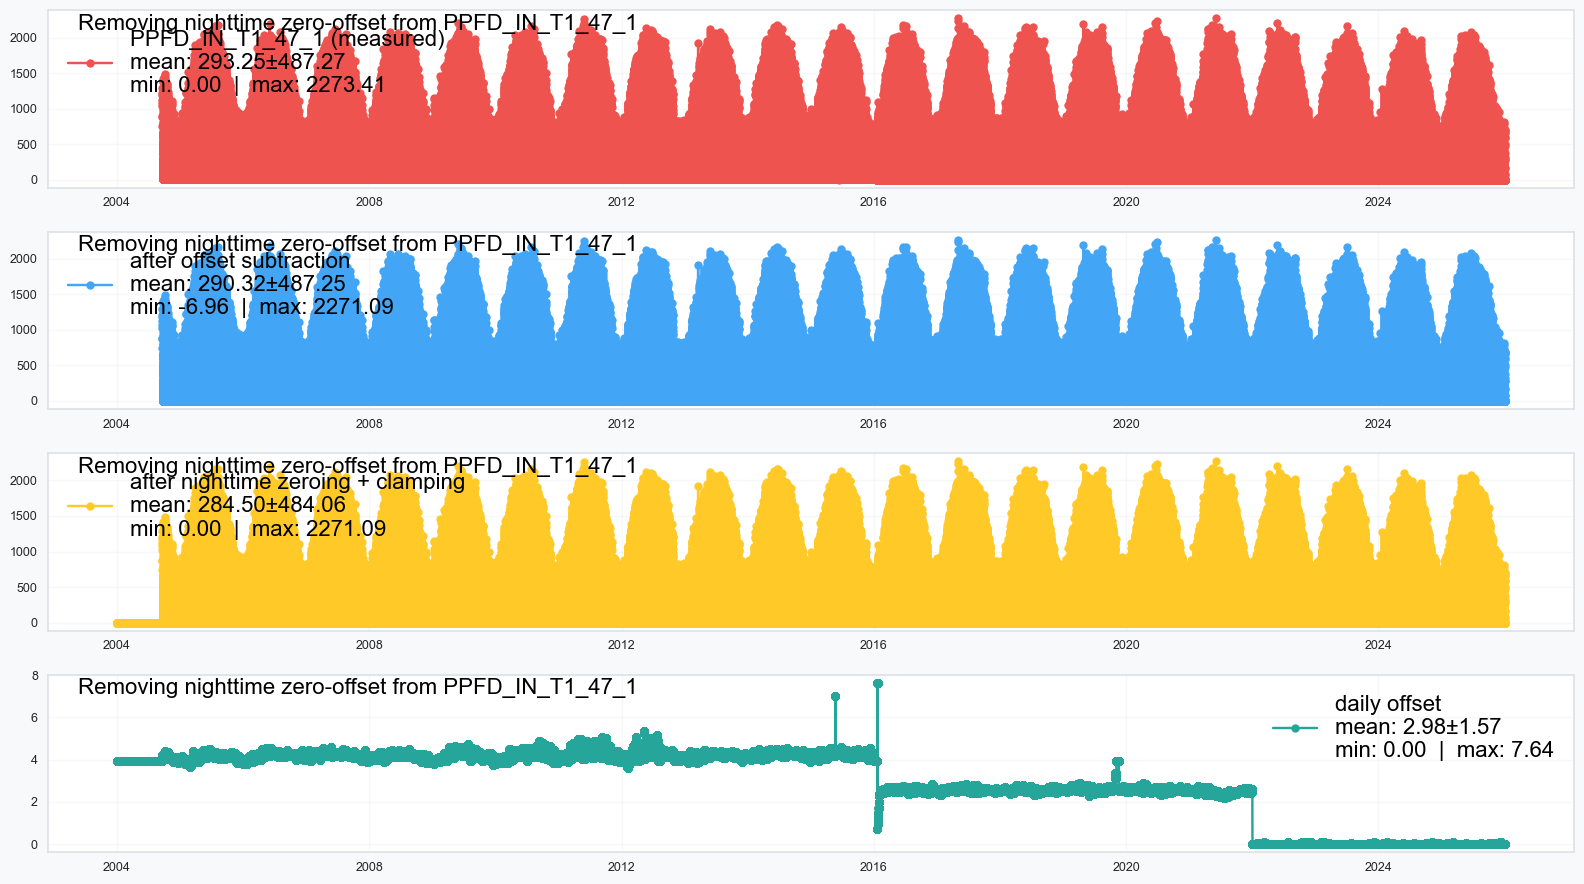

In [12]:
# Capture the gap mask BEFORE correcting. remove_nighttime_zero_offset() sets EVERY
# nighttime record to zero, including the missing ones, so afterwards a nighttime gap is
# indistinguishable from a nighttime measurement. Without this mask those filled zeros
# would reach the export flagged 0 = observed.
PPFD_ORIGINAL_GAPS = ppfd_2004_2025[TARGET].isna()
print(f"gaps before correction: {int(PPFD_ORIGINAL_GAPS.sum()):,}")

ppfd_corrected = dv.corrections.remove_nighttime_zero_offset(
    series=ppfd_2004_2025[TARGET].copy(),
    lat=SITE_LAT, lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    showplot=True, clamp_negatives=True,
)

_before = ppfd_2004_2025[TARGET]
print(f"before: min {_before.min():.2f}, records below zero: {(_before < 0).sum():,}")
print(f"after : min {ppfd_corrected.min():.2f}, records below zero: {(ppfd_corrected < 0).sum():,}")
print(f"mean change on measured records: {float((ppfd_corrected - _before).mean()):+.3f} umol m-2 s-1")
print(f"nighttime gaps zeroed by the correction: "
      f"{int((PPFD_ORIGINAL_GAPS & ppfd_corrected.notna()).sum()):,} "
      f"(fills, not measurements - flagged 3 by the gap-filler)")

ppfd_2004_2025[TARGET] = ppfd_corrected
ppfd_2004_2025.describe()

***

# 🟦 Drivers

`PPFD_IN` and `SW_IN` are two measurements of essentially the same flux in different units,
so the gap-filled `SW_IN` from notebook `01` is a far stronger driver than anything derived from
the timestamp. `SW_IN_POT` is added as well: it never has gaps and it carries sun angle and
season, which is what separates a clear morning from a clear afternoon of equal `SW_IN`.

Because `SW_IN` is complete over the whole record, the driver is available in every year. There
is therefore **no need to split the record into periods**, unlike notebooks `01` and `02` where
the NABEL sensor was only available until 2018.

In [13]:
swin_gf = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{SWIN_FILE}.parquet"))
print(f"Loaded {SWIN_FILE}: {list(swin_gf.columns)}")

drivers = pd.DataFrame(index=ppfd_2004_2025.index)
drivers[SWIN_COL] = swin_gf[SWIN_COL]  # keeps the name it has in the file
drivers['SW_IN_POT'] = dv.variables.potrad(
    timestamp_index=ppfd_2004_2025.index, lat=SITE_LAT, lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)

print(drivers.isnull().sum().rename('missing values'))
drivers.describe()

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\01_METEO
_SW_IN_GAPFILLED_2004-2025.parquet (0.044 seconds).

Loaded 01_METEO_SW_IN_GAPFILLED_2004-2025: ['SW_IN_T1_47_1_gfXG', 'FLAG_SW_IN_T1_47_1_ISFILLED']
SW_IN_T1_47_1_gfXG    0
SW_IN_POT             0
Name: missing values, dtype: int64


,SW_IN_T1_47_1_gfXG,SW_IN_POT
count,385728.000000,385728.000000
mean,145.499029,298.951202
std,239.720112,382.633189
min,0.000000,0.000000
25%,0.000000,0.000000
50%,4.008015,17.494992
75%,196.845521,566.632430
max,1118.658439,1214.125501


***

# 🟥 Gap-filling

## Method

There is no `PPFD_IN`-specific gap-filling class in diive, so this uses the general `XGBoostTS`
with an explicit `FeatureEngineer`, as notebook `02` does for `TA`. Two settings differ from the
temperature case, both because `PPFD_IN` is a radiation quantity:

- **`below_zero='zero'`** — negative predictions are clipped. Temperature can be negative,
  photon flux cannot.
- **Nighttime gaps are set to zero by physics** after modelling, and flagged `3`. There is no
  photosynthetically active radiation at night, so a modelled value there would be noise around a
  known answer. This mirrors what `SWINGapFillerXGBoost` does internally in notebook `01`.

Otherwise the configuration follows notebook `02`: no lag features (a lag of a gappy driver
demotes records to the timestamp-only fallback), `SW_IN_POT` excluded from the rolling and EMA
stages (smoothing a deterministic timestamp curve adds nothing), SHAP capped at 10,000 rows, and
short daytime gaps filled by interpolation afterwards and flagged `4`.

In [14]:
SHAP_MAX_ROWS = 10_000
NIGHTTIME_THRESHOLD = 0.001  # SW_IN_POT below this counts as night, as in notebook 01


def short_gap_mask(missing: pd.Series, limit: int) -> pd.Series:
    """True where `missing` is set AND its whole run is at most `limit` records long.

    Takes a boolean gap mask rather than the series itself, so the caller can pass the
    mask from before the nighttime offset correction.
    """
    run_length = missing.groupby((~missing).cumsum()).transform('sum')
    return missing & (run_length <= limit)


def gapfill_ppfd(target: pd.Series,
                 drivers: pd.DataFrame,
                 swinpot: pd.Series,
                 original_gaps: pd.Series,
                 interpolate_limit: int = 2,
                 reduce_features: bool = True,
                 verbose: int = 1):
    """Gap-fill PPFD with XGBoost, force nighttime to zero, interpolate short daytime gaps.

    `original_gaps` must be the gap mask from BEFORE the nighttime offset correction:
    that correction zeroes every nighttime record including the missing ones, so
    `target.isna()` here would report no nighttime gaps at all and label them as measured.

    Returns (model, gapfilled, flag).
    """
    daytime = swinpot >= NIGHTTIME_THRESHOLD

    input_df = pd.concat([target, drivers], axis=1)
    engineer = dv.gapfilling.FeatureEngineer(
        target_col=target.name,
        features_lag=[],
        features_rolling=[4, 8, 24, 48],
        features_rolling_stats=['median'],
        features_rolling_exclude_cols=['SW_IN_POT'],
        features_ema=[6, 24],
        features_ema_exclude_cols=['SW_IN_POT'],
        vectorize_timestamps=True,
        add_continuous_record_number=True,
        verbose=0,
    )
    features_df = engineer.fit_transform(input_df)
    print(f"Features: {features_df.shape[1] - 1} over {len(features_df):,} records")

    model = dv.gapfilling.XGBoostTS(
        input_df=features_df, target_col=target.name, verbose=verbose,
        below_zero='zero',           # photon flux cannot be negative
        shap_max_rows=SHAP_MAX_ROWS,
        n_estimators=3000, max_depth=6, early_stopping_rounds=20,
        random_state=42, n_jobs=-1,
    )
    model.trainmodel(showplot_scores=False, showplot_importance=False)
    if reduce_features:
        model.reduce_features()
        model.trainmodel(showplot_scores=False, showplot_importance=False)
    model.fillgaps(showplot_scores=False, showplot_importance=False)

    gapfilled = model.results.gapfilled.copy()
    flag = model.results.flag.copy()

    # Physics beats the model at night: no incoming PAR after sunset.
    night_gaps = original_gaps & ~daytime
    gapfilled[night_gaps] = 0.0
    flag[night_gaps] = 3
    print(f"Nighttime gaps set to 0: {int(night_gaps.sum()):,}")

    # Short DAYTIME gaps only - a night is already handled above. The run-length search
    # uses the pre-correction mask for the same reason as above.
    if interpolate_limit:
        short = short_gap_mask(original_gaps, interpolate_limit) & daytime
        interp = target.interpolate(method='time', limit_area='inside')
        fill_locs = short & interp.notna()
        gapfilled[fill_locs] = interp[fill_locs]
        flag[fill_locs] = 4
        print(f"Short-gap interpolation: {int(fill_locs.sum())} records")

    gapfilled = gapfilled.rename(f"{target.name}_gfXG")
    flag = flag.rename(f"FLAG_{target.name}_ISFILLED")
    return model, gapfilled, flag

## Run gap-filling

In [15]:
%%time

gf_ppfd, gapfilled_ppfd, flag_ppfd = gapfill_ppfd(
    target=ppfd_2004_2025[TARGET],
    drivers=drivers,
    swinpot=drivers['SW_IN_POT'],
    original_gaps=PPFD_ORIGINAL_GAPS,  # from BEFORE the offset correction, see there
)

Features: 31 over 385,728 records
Nighttime gaps set to 0: 7,543
Short-gap interpolation: 87 records
CPU times: total: 8min 9s
Wall time: 1min 11s


## Results: scores and feature importances

In [16]:
print("Held-out (train/test) scores:")
display(pd.Series(gf_ppfd.results.scores_traintest))
print("Flag counts:")
display(flag_ppfd.value_counts().sort_index().rename(index=FLAG_LEGEND))

Held-out (train/test) scores:


mae      8.199903e+00
medae    1.459643e+00
mse      4.829490e+02
rmse     2.197610e+01
mape     1.591057e+15
maxe     9.927937e+02
r2       9.979199e-01
dtype: float64

Flag counts:


FLAG_PPFD_IN_T1_47_1_ISFILLED
0 = observed                                          369124
1 = gap-filled by the XGBoost model                     8974
3 = nighttime gap, set to zero by physics               7543
4 = gap-filled by linear interpolation (short gap)        87
Name: count, dtype: int64

In [17]:
gf_ppfd.results.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
SW_IN_T1_47_1_gfXG,300.903656,263.616150
SW_IN_POT,37.411400,29.283054
.SW_IN_T1_47_1_gfXG_MEAN48,13.592666,11.301984
.SW_IN_T1_47_1_gfXG_ROLLMEDIAN4,7.964207,12.352504
.SW_IN_T1_47_1_gfXG_MEAN4,7.706210,8.767903
.SW_IN_T1_47_1_gfXG_EMA24,6.212327,8.321054
.DOY_COS,6.030526,6.021903
.DOY_SIN,5.882531,8.961789
.SW_IN_T1_47_1_gfXG_EMA6,5.410761,12.172805
.YEARMONTH,4.725764,5.581693


### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything implausible there is worth following
up, because it is invisible in the combined series.

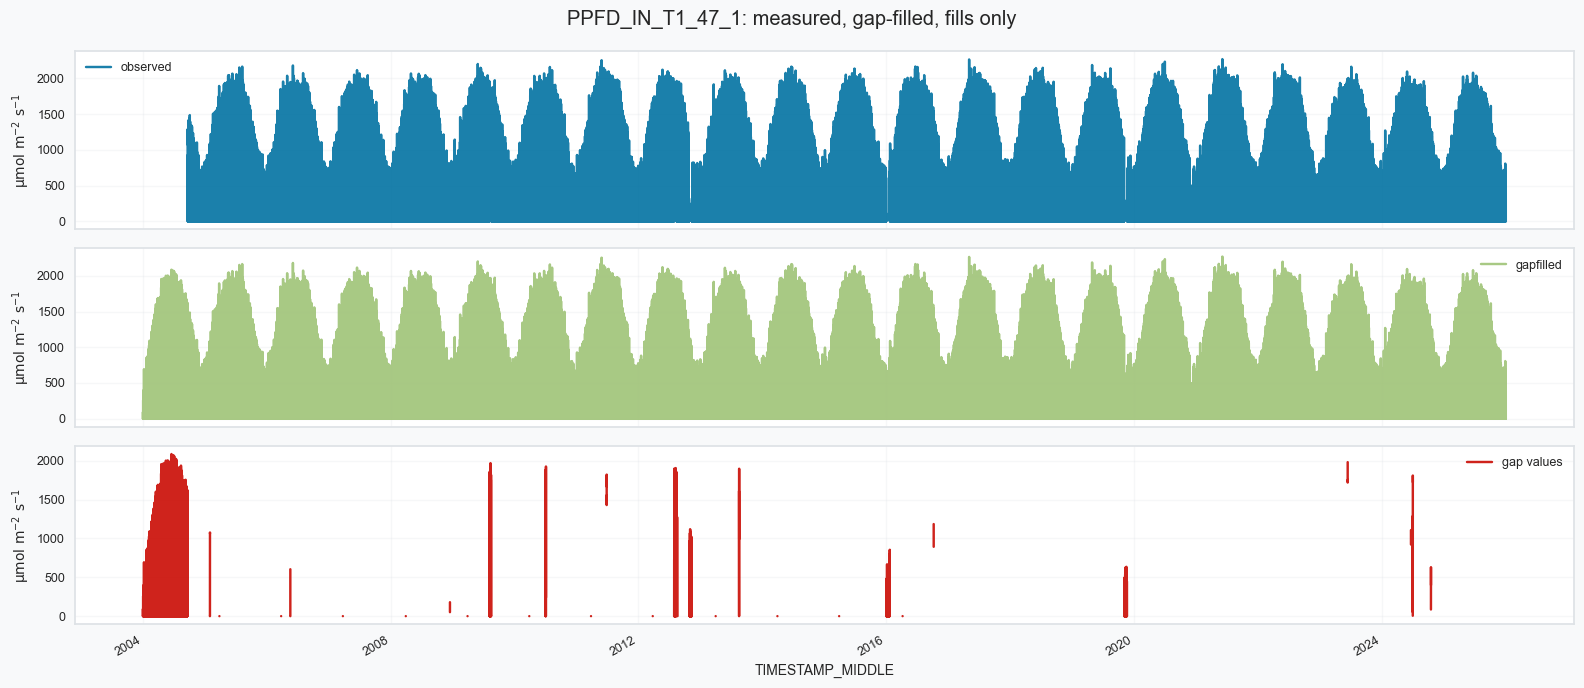

In [18]:
plot_gapfill_panels(gapfilled_ppfd, flag_ppfd,
                    title=f"{TARGET}: measured, gap-filled, fills only");

### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this shows whether it is actually any good.

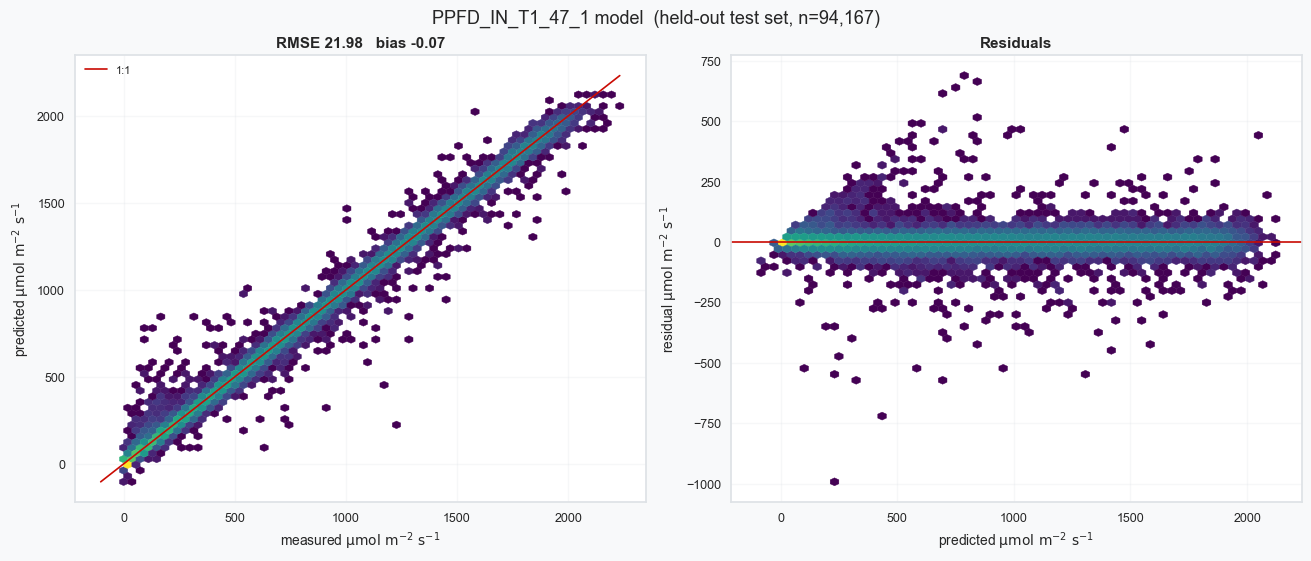

In [19]:
plot_pred_vs_measured(gf_ppfd, title=f"{TARGET} model");

***

# ➡️ Prepare dataframe for export

In [20]:
VALCOL = f"{TARGET}_gfXG"
FLAGCOL = f"FLAG_{TARGET}_ISFILLED"

export_df = pd.concat([gapfilled_ppfd, flag_ppfd], axis=1)
export_df

,PPFD_IN_T1_47_1_gfXG,FLAG_PPFD_IN_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,3
2004-01-01 00:45:00,0.0,3
2004-01-01 01:15:00,0.0,3
2004-01-01 01:45:00,0.0,3
2004-01-01 02:15:00,0.0,3
...,...,...
2025-12-31 21:45:00,0.0,0
2025-12-31 22:15:00,0.0,0
2025-12-31 22:45:00,0.0,0


Sanity check: the exported series must be complete, non-negative, on a continuous 30MIN index
with no duplicates, and every record must carry a flag.

`FLAG_PPFD_IN_T1_47_1_ISFILLED` travels with the product so downstream notebooks can tell measured
from filled records.

In [21]:
print(f"Records:         {len(export_df)}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Min / max:       {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f}")

print("\nFill provenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
display(pd.DataFrame({'count': _counts,
                      '%': (100 * _counts / len(export_df)).round(2)}).rename(index=FLAG_LEGEND))
print(f"Measured: {100 * (export_df[FLAGCOL] == 0).mean():.2f}%  |  "
      f"Filled: {100 * (export_df[FLAGCOL] > 0).mean():.2f}%")

export_df.describe()

Records:         385728
Missing values:  0
Negative values: 0
Missing flags:   0
Duplicate index: 0
Index gaps:      0
Min / max:       0.00 / 2271.09

Fill provenance:


,count,%
FLAG_PPFD_IN_T1_47_1_ISFILLED,,
0 = observed,369124,95.70
1 = gap-filled by the XGBoost model,8974,2.33
"3 = nighttime gap, set to zero by physics",7543,1.96
4 = gap-filled by linear interpolation (short gap),87,0.02


Measured: 95.70%  |  Filled: 4.30%


,PPFD_IN_T1_47_1_gfXG,FLAG_PPFD_IN_T1_47_1_ISFILLED
count,385728.000000,385728.000000
mean,291.514753,0.082833
std,488.494485,0.442730
min,0.000000,0.000000
25%,0.000000,0.000000
50%,6.421284,0.000000
75%,376.405724,0.000000
max,2271.086339,4.000000


## Fill statistics per year

**Note on 2004.** `PPFD_IN` measurements only start on 20 September 2004, so everything before
that is modelled. Those records are filled from the gap-filled `SW_IN` of notebook `01`, which is
itself reconstructed for 2004 from the NABEL sensor. They are therefore a fill built on a fill and
carry the uncertainty of both steps. The flag marks them, so they can be excluded where that
matters.

,0 = observed,1 = gap-filled by the XGBoost model,"3 = nighttime gap, set to zero by physics",4 = gap-filled by linear interpolation (short gap)
year,,,,
2004,4922,7089,5556,1
2005,17485,10,17,8
2006,17493,5,14,8
2007,17507,0,6,7
2008,17548,4,8,8
2009,17036,292,184,8
2010,17351,109,55,5
2011,17499,10,6,5
2012,16310,656,596,6


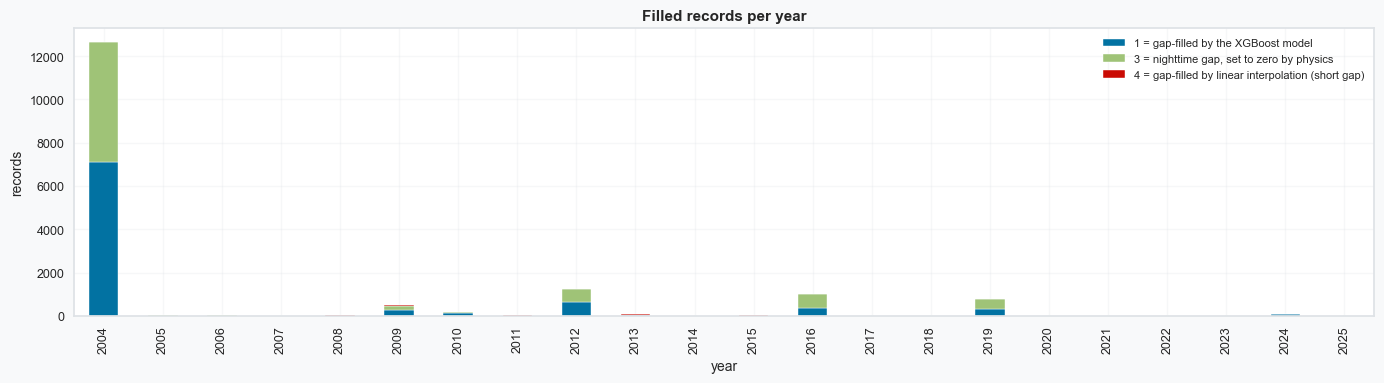

In [22]:
fill_stats_by_year(export_df[FLAGCOL])

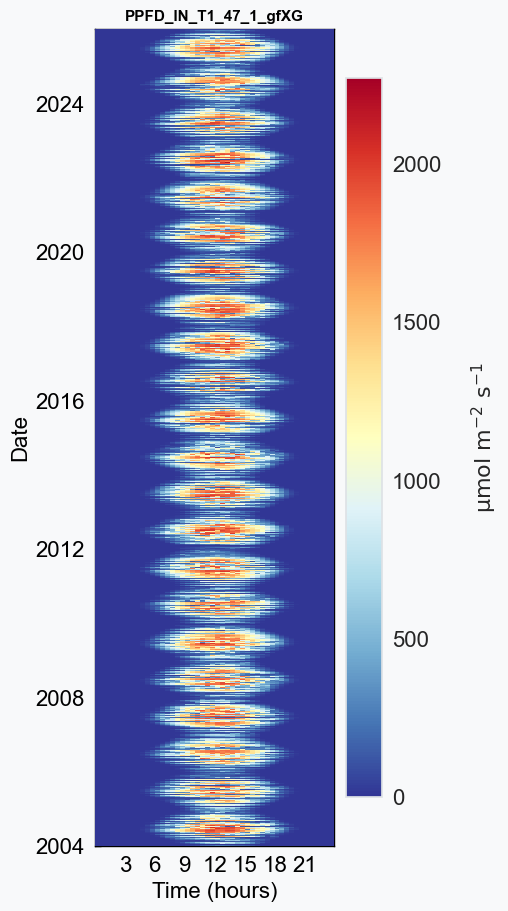

In [23]:
fig, ax = plt.subplots(figsize=(5, 9), dpi=100, layout="constrained")
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

***

# 💾 Save to file

In [24]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\03_METEO
_PPFD_IN_GAPFILLED_2004-2025.parquet (0.058 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\03_METEO_PPFD_IN_GAPFILLED_2004-2025.parquet


***

# End of notebook.

In [25]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-20 01:02:57
Finished: 2026-07-20 01:04:44
Runtime:  00:01:47 (hh:mm:ss)
